<a href="https://colab.research.google.com/github/shakhawat25/GITLABTASK/blob/main/CVPR3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SkySeaLand Satellite Object Detection Dataset

DOI:10.17632/d42n3cp86p.1


In this project, we performed four-class image classification using a basic convolutional neural network in PyTorch. The original dataset was in COCO annotation format, so we read the JSON annotations, used bounding boxes to crop the objects, and organized the images into airplane, boat, car, and ship folders. We created separate training, validation, and test datasets. In Round 1, we trained a basic CNN using resized tensor images without augmentation or dropout. We analyzed the model using loss and accuracy curves, learned filters, feature maps, a confusion matrix, and a classification report. In Round 2, we created a fresh CNN and added random horizontal flipping, rotation, brightness and contrast changes, and 50% dropout. We compared both rounds using validation curves and training-validation gaps. Finally, we evaluated both models on a separate unseen test set and compared their test accuracies using classification reports, confusion matrices, and a bar chart.



In [ ]:
# ============================================================
# Cell 1: Import libraries and prepare the environment
# ============================================================
# Ei cell e project er jonno necessary library gula import kora hobe
# ebong model CPU naki GPU te run korbe seta select kora hobe


import torch
# PyTorch er main library import kortesi
# tensor create, GPU use, model training er main kaj gula torch handle kore

import torch.nn as nn
# neural network er layer gula use korar jonno nn import kortesi

import torch.nn.functional as F
# activation function and functional operation use korar jonno F import kortesi


from torchvision import datasets, transforms
# datasets diye ImageFolder use kora jabe
# transforms diye image resize, flip, rotation, ToTensor kora jabe

from torch.utils.data import DataLoader
# DataLoader dataset theke image gula small batch e model er kache pathabe
# eta training fast and organized kore



import matplotlib.pyplot as plt
# training graph, image, filter, feature map, and result plot korar jonno

import numpy as np
# numerical calculation and array related kaj korar jonno NumPy use korbo



import os
# file path, folder checking, folder list, and operating system related kajer jonno

import json
# COCO annotation er _annotations.coco.json file read korar jonno

import math
# bounding box coordinates floor and ceil korar jonno math use korbo

import shutil
# folder remove, copy, and organize korar jonno shutil use korbo

import zipfile
# uploaded dataset ZIP file extract korar jonno



from pathlib import Path

from collections import Counter, defaultdict
# Counter diye protita class er image/object count kora jabe
# defaultdict diye image ID onujayi annotations group kora jabe



from PIL import Image
# image open, RGB te convert, bounding box diye crop,
# and new image file save korar jonno PIL Image use korbo



# CUDA-supported GPU available ache kina check kortesi
# GPU available hole "cuda", otherwise "cpu" select korbe
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# model kon device e run korbe seta output e show korbe
print("Using device:", device)


# Random seed fixed rakha hocche
# same code abar run korle similar random result pawar jonno
torch.manual_seed(0)
# PyTorch er random operation gula reproducible korar jonno seed set kortesi

np.random.seed(0)
# NumPy er random operation gula reproducible korar jonno seed set kortesi

Using device: cpu


In [ ]:
# ============================================================
# Cell 2: Upload and extract the SkySeaLand ZIP file
# ============================================================
# Ei cell e dataset ZIP file locate, upload, and extract kora hobe


from google.colab import files
# Colab theke manually file upload korar jonno


# Colab er /content folder e SkySeaLand dataset ZIP ache kina check korbe
zip_candidates = list(
    Path("/content").glob("SkySeaLand_coco*.zip")
)


# ZIP file already na thakle upload option dibe
if len(zip_candidates) == 0:
    print("Please upload SkySeaLand_coco.zip")

    uploaded_files = files.upload()

    # Uploaded file gula theke only ZIP file select kortesi
    zip_candidates = [
        Path("/content") / file_name
        for file_name in uploaded_files.keys()
        if file_name.lower().endswith(".zip")
    ]


# Upload er poro ZIP file na pele error dibe
if len(zip_candidates) == 0:
    raise FileNotFoundError(
        "SkySeaLand COCO ZIP file was not found."
    )


# Matching ZIP file gula theke first file select kortesi
ZIP_PATH = zip_candidates[0]

print("ZIP file found:", ZIP_PATH)


# Dataset extract korar folder path
EXTRACT_DIR = "/content/SkySeaLand_coco_extracted"


# Age extract kora folder thakle remove kore fresh extraction korbe
# eta old file ba duplicate data avoid korte help kore
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)


# Extraction folder create kortesi
# exist_ok=True hole folder age theke thakleo error dibe na
os.makedirs(EXTRACT_DIR, exist_ok=True)


# Selected ZIP file EXTRACT_DIR folder e extract kortesi
with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extractall(EXTRACT_DIR)


# Extraction successful hole folder information print korbe
print("Dataset extracted successfully.")
print("Extraction folder:", EXTRACT_DIR)

ZIP file found: /content/SkySeaLand_coco.zip
Dataset extracted successfully.
Extraction folder: /content/SkySeaLand_coco_extracted


In [ ]:
# ============================================================
# Cell 3: Find train, valid, and test folders
# ============================================================
# Ei cell e extracted dataset er actual root folder locate kora hobe
# ebong train, valid, test folder properly ache kina check kora hobe


def find_coco_dataset_root(search_root):
    """
    Ei function emon folder khujbe jar moddhe:
    train, valid, and test folder ache
    and protita folder e _annotations.coco.json ache.
    """

    # Extracted folder er vitore sob folder serially check kortesi
    for current_folder, subfolders, files_in_folder in os.walk(search_root):

        # Train annotation file er expected path
        train_annotation = os.path.join(
            current_folder,
            "train",
            "_annotations.coco.json"
        )

        # Validation annotation file er expected path
        valid_annotation = os.path.join(
            current_folder,
            "valid",
            "_annotations.coco.json"
        )

        # Test annotation file er expected path
        test_annotation = os.path.join(
            current_folder,
            "test",
            "_annotations.coco.json"
        )

        # Tin ta annotation file same root folder er moddhe ache kina check kortesi
        if (
            os.path.exists(train_annotation)
            and os.path.exists(valid_annotation)
            and os.path.exists(test_annotation)
        ):
            return current_folder

    # Proper dataset root na pele None return korbe
    return None


# Extracted dataset theke actual COCO root folder locate kortesi
COCO_ROOT = find_coco_dataset_root(EXTRACT_DIR)


# Root folder locate na hole clear error dibe
if COCO_ROOT is None:
    raise FileNotFoundError(
        "COCO train, valid, and test folders were not found."
    )


# Located dataset root path print kortesi
print("COCO dataset root:", COCO_ROOT)


# Train folder properly ache kina check kore output show korbe
print(
    "Train folder exists:",
    os.path.exists(os.path.join(COCO_ROOT, "train"))
)


# Validation folder properly ache kina check kore output show korbe
print(
    "Validation folder exists:",
    os.path.exists(os.path.join(COCO_ROOT, "valid"))
)


# Test folder properly ache kina check kore output show korbe
print(
    "Test folder exists:",
    os.path.exists(os.path.join(COCO_ROOT, "test"))
)

COCO dataset root: /content/SkySeaLand_coco_extracted
Train folder exists: True
Validation folder exists: True
Test folder exists: True


In [ ]:
# ============================================================
# Cell 4: Check original images, classes, and annotations
# ============================================================
# Ei cell e train, valid, and test split er original image,
# object annotation, class count, and multi-class image count check kora hobe


# Dataset er tin ta split serially check korar jonno
source_splits = ["train", "valid", "test"]


# Protita split ek ek kore process kortesi
for split_name in source_splits:

    # Current split er COCO annotation file path banacchi
    annotation_path = os.path.join(
        COCO_ROOT,
        split_name,
        "_annotations.coco.json"
    )

    # COCO annotation JSON file read kortesi
    with open(annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    # Category ID theke actual class name mapping banacchi
    # "objects" placeholder class tai ignore kortesi
    category_map = {
        category["id"]: category["name"]
        for category in coco_data["categories"]
        if category["name"].lower() != "objects"
    }

    # Protita class e koyta object annotation ache seta count korbe
    object_counts = Counter()

    # Ek image e koyta different class ache seta track korar jonno
    image_classes = defaultdict(set)

    # Sob annotations serially check kortesi
    for annotation in coco_data["annotations"]:

        category_id = annotation["category_id"]

        # Annotation er category actual target class hole process korbe
        if category_id in category_map:

            class_name = category_map[category_id]

            # Current class er object count 1 barabe
            object_counts[class_name] += 1

            # Current image ID er sathe class name store kortesi
            image_classes[
                annotation["image_id"]
            ].add(class_name)

    # Ek image e 1 er beshi different class ache emon image count kortesi
    multi_class_image_count = sum(
        1
        for classes_in_image in image_classes.values()
        if len(classes_in_image) > 1
    )

    # Current split er summary print kortesi
    print("\n" + "=" * 60)
    print(split_name.upper(), "DATASET INFORMATION")
    print("=" * 60)

    print("Original images:", len(coco_data["images"]))
    print("Object annotations:", sum(object_counts.values()))
    print("Multiple-class images:", multi_class_image_count)

    print("Object counts by class:")

    # Class name alphabetical order e count print korbe
    for class_name in sorted(object_counts.keys()):
        print(
            f"  {class_name}: {object_counts[class_name]}"
        )


TRAIN DATASET INFORMATION
Original images: 1048
Object annotations: 15036
Multiple-class images: 144
Object counts by class:
  airplane: 3927
  boat: 2706
  car: 5455
  ship: 2948

VALID DATASET INFORMATION
Original images: 132
Object annotations: 1992
Multiple-class images: 21
Object counts by class:
  airplane: 367
  boat: 657
  car: 679
  ship: 289

TEST DATASET INFORMATION
Original images: 127
Object annotations: 2075
Multiple-class images: 18
Object counts by class:
  airplane: 553
  boat: 334
  car: 798
  ship: 390


In [ ]:
# ============================================================
# Cell 5: Convert COCO bounding boxes into class folders
# ============================================================
#
# Faculty er ImageFolder code use korte hole folder structure:
#
# train/
# ├── airplane/
# ├── boat/
# ├── car/
# └── ship/
#
# Ekta original satellite image e multiple object thakte pare.
# Tai protita bounding box theke separate image crop create hobe.
#
# Example:
# Original image e airplane and car thakle:
# airplane er crop airplane folder e jabe
# car er crop car folder e jabe
# ============================================================


# Organized classification dataset save korar main folder
CLASSIFICATION_ROOT = (
    "/content/SkySeaLand_classification"
)


# Purono organized folder thakle remove korbe
# jate duplicate ba old files na thake
if os.path.exists(CLASSIFICATION_ROOT):
    shutil.rmtree(CLASSIFICATION_ROOT)


# Notun classification root folder create kortesi
os.makedirs(CLASSIFICATION_ROOT, exist_ok=True)


# Original split name ke ImageFolder-friendly output name e map kortesi
split_name_mapping = {
    "train": "train",
    "valid": "validation",
    "test": "test"
}


# Train, validation, and test split ek ek kore process kortesi
for source_split, output_split in split_name_mapping.items():

    # Current source split folder er path
    source_split_folder = os.path.join(
        COCO_ROOT,
        source_split
    )

    # Current split er COCO annotation JSON file path
    annotation_path = os.path.join(
        source_split_folder,
        "_annotations.coco.json"
    )

    # Annotation file read kortesi
    with open(annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    # Category ID theke actual four class er name mapping banacchi
    # "objects" placeholder category ignore kortesi
    category_map = {
        category["id"]: category["name"]
        for category in coco_data["categories"]
        if category["name"].lower() != "objects"
    }

    # Image ID diye corresponding image information khuje pawar jonno
    image_information = {
        image_item["id"]: image_item
        for image_item in coco_data["images"]
    }

    # Protita image er annotations ek jaygay group kortesi
    annotations_by_image = defaultdict(list)

    for annotation in coco_data["annotations"]:

        # Only actual target class er annotations store korbe
        if annotation["category_id"] in category_map:

            annotations_by_image[
                annotation["image_id"]
            ].append(annotation)

    # Current output split er moddhe four ta class folder create kortesi
    for class_name in sorted(category_map.values()):

        class_folder = os.path.join(
            CLASSIFICATION_ROOT,
            output_split,
            class_name
        )

        os.makedirs(class_folder, exist_ok=True)

    # Current split er class-wise crop count store korbe
    class_counts = Counter()

    # Invalid bounding box count korar jonno
    invalid_boxes = 0

    # Open/read kora jay nai emon image count korar jonno
    unreadable_images = 0

    total_images = len(coco_data["images"])

    print(
        f"\nOrganizing {source_split} split..."
    )

    # Protita original image ek ek kore process kortesi
    for image_number, image_item in enumerate(
        coco_data["images"]
    ):

        image_id = image_item["id"]

        # Current image file er full path
        image_path = os.path.join(
            source_split_folder,
            image_item["file_name"]
        )

        try:
            # Original satellite image open kortesi
            with Image.open(image_path) as original_image:

                # CNN RGB input use kore, tai image RGB te convert kortesi
                original_image = original_image.convert("RGB")

                image_width, image_height = (
                    original_image.size
                )

                # Current image er protita annotated object process korbe
                for annotation in annotations_by_image[image_id]:

                    # Annotation er class name ber kortesi
                    class_name = category_map[
                        annotation["category_id"]
                    ]

                    # COCO bounding box format:
                    # x, y, width, height
                    x, y, box_width, box_height = (
                        annotation["bbox"]
                    )

                    # Bounding box er starting coordinates safe integer e convert kortesi
                    x1 = max(0, math.floor(x))
                    y1 = max(0, math.floor(y))

                    # Bounding box er ending coordinates image boundary er moddhe rakhtesi
                    x2 = min(
                        image_width,
                        math.ceil(x + box_width)
                    )

                    y2 = min(
                        image_height,
                        math.ceil(y + box_height)
                    )

                    # Width ba height zero/negative hole invalid box hisebe skip korbe
                    if x2 <= x1 or y2 <= y1:
                        invalid_boxes += 1
                        continue

                    # Bounding box area theke specific object crop kortesi
                    object_crop = original_image.crop(
                        (x1, y1, x2, y2)
                    )

                    # Protita crop er jonno unique output file name banacchi
                    output_file_name = (
                        f"{Path(image_item['file_name']).stem}"
                        f"_object_{annotation['id']}.jpg"
                    )

                    # Crop image kon split and class folder e save hobe
                    output_path = os.path.join(
                        CLASSIFICATION_ROOT,
                        output_split,
                        class_name,
                        output_file_name
                    )

                    # Crop image JPEG format e save kortesi
                    object_crop.save(
                        output_path,
                        format="JPEG",
                        quality=95
                    )

                    # Current class er crop count 1 barabe
                    class_counts[class_name] += 1

        except Exception as error:

            # Image open/process na hole unreadable count 1 barabe
            unreadable_images += 1

            print(
                "Could not process image:",
                image_path,
                error
            )

        # Prottek 100 image por progress show korbe
        # last image process holeo final progress print korbe
        if (
            (image_number + 1) % 100 == 0
            or image_number + 1 == total_images
        ):
            print(
                f"Processed {image_number + 1}"
                f"/{total_images} original images"
            )

    # Current split complete hole summary print korbe
    print("\nCompleted:", output_split)

    # Class-wise total crop count print kortesi
    for class_name in sorted(category_map.values()):
        print(
            f"{class_name}: {class_counts[class_name]}"
        )

    print("Total object crops:", sum(class_counts.values()))
    print("Invalid bounding boxes skipped:", invalid_boxes)
    print("Unreadable images:", unreadable_images)


Organizing train split...
Processed 100/1048 original images
Processed 200/1048 original images
Processed 300/1048 original images
Processed 400/1048 original images
Processed 500/1048 original images
Processed 600/1048 original images
Processed 700/1048 original images
Processed 800/1048 original images
Processed 900/1048 original images
Processed 1000/1048 original images
Processed 1048/1048 original images

Completed: train
airplane: 3927
boat: 2706
car: 5454
ship: 2948
Total object crops: 15035
Invalid bounding boxes skipped: 1
Unreadable images: 0

Organizing valid split...
Processed 100/132 original images
Processed 132/132 original images

Completed: validation
airplane: 367
boat: 657
car: 679
ship: 289
Total object crops: 1992
Invalid bounding boxes skipped: 0
Unreadable images: 0

Organizing test split...
Processed 100/127 original images
Processed 127/127 original images

Completed: test
airplane: 553
boat: 334
car: 798
ship: 390
Total object crops: 2075
Invalid bounding box

In [ ]:
# ============================================================
# Cell 6: Verify organized class folders and image counts
# ============================================================
# Ei cell e organized train, validation, and test folder gula check kora hobe
# ebong protita class e koyta image ache seta count kora hobe


# Training folder er path
train_dir = os.path.join(
    CLASSIFICATION_ROOT,
    "train"
)

# Validation folder er path
val_dir = os.path.join(
    CLASSIFICATION_ROOT,
    "validation"
)

# Test folder er path
test_dir = os.path.join(
    CLASSIFICATION_ROOT,
    "test"
)


# Tin ta folder er full path print kortesi
print("Training folder:", train_dir)
print("Validation folder:", val_dir)
print("Testing folder:", test_dir)


# Training folder er vitore kon kon class folder ache seta show korbe
print("\nClasses inside training folder:")
print(sorted(os.listdir(train_dir)))


# Train, validation, and test split ek ek kore check kortesi
for split_title, split_folder in [
    ("TRAIN", train_dir),
    ("VALIDATION", val_dir),
    ("TEST", test_dir)
]:

    # Current split er heading print korbe
    print("\n" + "=" * 50)
    print(split_title)
    print("=" * 50)

    # Current split er total image count
    split_total = 0

    # Protita class folder alphabetical order e check kortesi
    for class_name in sorted(os.listdir(split_folder)):

        # Current class folder er full path
        class_path = os.path.join(
            split_folder,
            class_name
        )

        # Only image file gula list e store kortesi
        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        # Current class er image count print korbe
        print(
            f"{class_name}: {len(image_files)}"
        )

        # Current class er count split total er sathe add kortesi
        split_total += len(image_files)

    # Current split er total image count print korbe
    print("Total:", split_total)

Training folder: /content/SkySeaLand_classification/train
Validation folder: /content/SkySeaLand_classification/validation
Testing folder: /content/SkySeaLand_classification/test

Classes inside training folder:
['airplane', 'boat', 'car', 'ship']

TRAIN
airplane: 3927
boat: 2706
car: 5454
ship: 2948
Total: 15035

VALIDATION
airplane: 367
boat: 657
car: 679
ship: 289
Total: 1992

TEST
airplane: 553
boat: 334
car: 798
ship: 390
Total: 2075


In [ ]:
# ============================================================
# Cell 7: Round 1 basic transformation and DataLoader
# ============================================================
#
# Round 1 e augmentation use kora hobe na.
# Faculty sample er moto:
# 1) Resize
# 2) ToTensor
# ============================================================


# Sob image 128 × 128 size e convert hobe
IMG_SIZE = 128

# Model ekbare 32 ta image process korbe
BATCH_SIZE = 32


# Round 1 er basic transformation
basic_transform = transforms.Compose([

    # Sob images ke same size e convert korbe
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    # Image ke PyTorch tensor e convert korbe
    # pixel range 0 theke 1 hobe
    transforms.ToTensor(),
])


# ImageFolder class folder er name diye automatically label create korbe
train_ds = datasets.ImageFolder(
    train_dir,
    transform=basic_transform
)

val_ds = datasets.ImageFolder(
    val_dir,
    transform=basic_transform
)

test_ds = datasets.ImageFolder(
    test_dir,
    transform=basic_transform
)


# Training images 32 ta kore batch e model er kache jabe
# shuffle=True training er age image order randomly change korbe
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# Validation and test e shuffle=False
# karon ekhane model train korbe na, only performance check korbe
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Detected class names and automatic label mapping print korbe
print("Classes:", train_ds.classes)
print("Class label mapping:", train_ds.class_to_idx)


# Protita split e total koyta object image ache seta print korbe
print("\nTraining object images:", len(train_ds))
print("Validation object images:", len(val_ds))
print("Testing object images:", len(test_ds))


# Train, validation, and test e class order same ache kina check korbe
assert train_ds.class_to_idx == val_ds.class_to_idx
assert train_ds.class_to_idx == test_ds.class_to_idx

print("\nClass mappings are the same in all splits.")

Classes: ['airplane', 'boat', 'car', 'ship']
Class label mapping: {'airplane': 0, 'boat': 1, 'car': 2, 'ship': 3}

Training object images: 15035
Validation object images: 1992
Testing object images: 2075

Class mappings are the same in all splits.


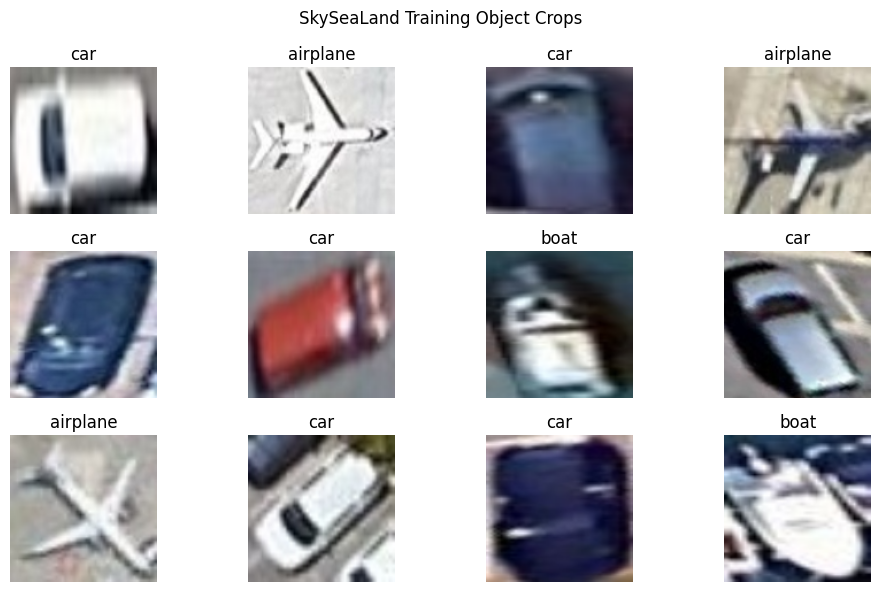

In [ ]:
# ============================================================
# Cell 8: Display some training images
# ============================================================
# Ei cell e training dataset theke kichu sample image
# tader corresponding class label shoho display kora hobe


# Training DataLoader theke one batch nicchi
images, labels = next(iter(train_loader))

# Class index ke class name e convert korar jonno
class_names = train_ds.classes


# Figure size set kortesi
plt.figure(figsize=(10, 6))


# Batch theke first 12 ta image display korbo
for i in range(12):

    # 3 row and 4 column er subplot create korbe
    plt.subplot(3, 4, i + 1)

    # PyTorch tensor shape = [C, H, W]
    # Matplotlib image shape = [H, W, C]
    plt.imshow(
        images[i].permute(1, 2, 0)
    )

    # Folder label theke corresponding class name show korbe
    plt.title(
        class_names[labels[i]]
    )

    # Axis line and number hide korbe
    plt.axis("off")


# Full figure er main title
plt.suptitle("SkySeaLand Training Object Crops")

# Subplot gula neatly arrange korbe
plt.tight_layout()

# Final image grid display korbe
plt.show()

In [ ]:
# ============================================================
# Cell 9: Build the basic CNN from scratch
# ============================================================
#
# Faculty model er same structure:
#
# Conv1: 3 channels -> 16 filters
# Conv2: 16 filters -> 32 filters
# Conv3: 32 filters -> 64 filters
#
# Final output:
# 4 scores for airplane, boat, car, and ship
# ============================================================


# Simple CNN model class create kortesi
class SimpleCNN(nn.Module):

    def __init__(self, p_dropout=0.0):

        super().__init__()

        # ---------------- Feature extractor ----------------

        # First convolution layer
        # RGB image er 3 channel theke 16 ta feature map create korbe
        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            padding=1
        )

        # Second convolution layer
        # 16 ta feature map theke 32 ta feature map create korbe
        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        # Third convolution layer
        # 32 ta feature map theke 64 ta feature map create korbe
        self.conv3 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        # Protibar image er height and width half kore dibe
        self.pool = nn.MaxPool2d(
            2,
            2
        )

        # ---------------- Classification head ----------------

        # Round 1 e p_dropout = 0.0
        # Round 2 e p_dropout = 0.5
        self.dropout = nn.Dropout(
            p_dropout
        )

        # 128 × 128 image three times pooling er por:
        # 128 -> 64 -> 32 -> 16
        # Final 64 × 16 × 16 feature gula 128 neuron e convert korbe
        self.fc1 = nn.Linear(
            64 * 16 * 16,
            128
        )

        # Final output e four class er score dibe
        self.fc2 = nn.Linear(
            128,
            4
        )


    # Input image model er moddhe kon order e process hobe
    def forward(self, x):

        # First convolution, ReLU, and pooling
        x = self.pool(
            F.relu(self.conv1(x))
        )

        # Image size: 128 -> 64

        # Second convolution, ReLU, and pooling
        x = self.pool(
            F.relu(self.conv2(x))
        )

        # Image size: 64 -> 32

        # Third convolution, ReLU, and pooling
        x = self.pool(
            F.relu(self.conv3(x))
        )

        # Image size: 32 -> 16

        # Feature maps ke one long vector e convert korbe
        x = torch.flatten(x, 1)

        # Dropout apply korbe
        x = self.dropout(x)

        # First fully connected layer and ReLU
        x = F.relu(self.fc1(x))

        # Airplane, boat, car, and ship er four ta raw score dibe
        x = self.fc2(x)

        return x


# Round 1 model e dropout off rakhtesi
model = SimpleCNN(
    p_dropout=0.0
).to(device)

# Full model structure print korbe
print(model)


# Model e total koyta trainable parameter ache seta calculate kortesi
n_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    f"\nTotal trainable parameters: {n_params:,}"
)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

Total trainable parameters: 2,121,380


In [ ]:
# ============================================================
# Cell 10: Training and validation function
# ============================================================
#
# Ei function model ke train korbe and protita epoch er por
# validation dataset diye model er performance check korbe.
#
# Ekhane faculty sample er baire kono extra technique use hoy nai:
#
# No class weighting
# No early stopping
# No best epoch saving
# No learning-rate scheduler
#
# Model fixed number of epochs porjonto train korbe.
# ============================================================


# train_model name e function create kortesi
def train_model(

    # Je CNN model train korte chai seta function e ashbe
    model,

    # Training images er DataLoader
    train_loader,

    # Validation images er DataLoader
    val_loader,

    # Default training epoch 15
    epochs=15,

    # Default learning rate 0.001
    # 1e-3 same as 0.001
    lr=1e-3
):

    # CrossEntropyLoss multi-class classification er loss calculate kore
    # Amader 4 ta class: airplane, boat, car, and ship
    criterion = nn.CrossEntropyLoss()


    # Adam optimizer model er parameters ba weights update korbe
    optimizer = torch.optim.Adam(

        # Model er sob trainable weight optimizer ke dicchi
        model.parameters(),

        # Weight update er step size
        lr=lr
    )


    # Protita epoch er loss and accuracy ekhane save hobe
    # Pore ei values use kore graph draw kora jabe
    history = {

        # Training loss save korbe
        "train_loss": [],

        # Validation loss save korbe
        "val_loss": [],

        # Training accuracy save korbe
        "train_acc": [],

        # Validation accuracy save korbe
        "val_acc": []
    }


    # Training fixed number of epochs porjonto run korbe
    # Example: epochs=15 hole loop 15 bar run korbe
    for epoch in range(epochs):


        # ====================================================
        # TRAINING
        # ====================================================

        # Model ke training mode e set kortesi
        # Dropout thakle training mode e active thakbe
        model.train()


        # Current epoch er total loss store korbe
        running_loss = 0.0

        # Current epoch e koyta correct prediction holo
        correct = 0

        # Current epoch e total koyta image process holo
        total = 0


        # Training DataLoader theke batch by batch data nicchi
        # imgs = ek batch image
        # labels = images gulor actual class label
        for imgs, labels in train_loader:


            # Images selected device e pathacchi
            # GPU available hole GPU, otherwise CPU
            imgs = imgs.to(device)

            # Labels o same device e pathacchi
            labels = labels.to(device)


            # Previous batch er gradient clear kortesi
            # Eta na korle old and new gradient add hoye jabe
            optimizer.zero_grad()


            # Images model er moddhe pathiye prediction scores nicchi
            outputs = model(imgs)


            # Model prediction and actual label compare kore loss calculate korbe
            loss = criterion(
                outputs,
                labels
            )


            # Loss theke backward direction e gradient calculate korbe
            loss.backward()


            # Calculated gradient use kore model er weights update korbe
            optimizer.step()


            # Current batch er average loss ke batch size diye multiply kortesi
            # Jate full epoch er total loss calculate kora jay
            running_loss += (
                loss.item() * imgs.size(0)
            )


            # Protita image er 4 ta output score theke
            # highest score er index final prediction hobe
            predicted_labels = outputs.argmax(1)


            # Predicted label actual label er sathe match korle
            # correct prediction count er sathe add korbe
            correct += (
                predicted_labels == labels
            ).sum().item()


            # Current batch e koyta image ache seta total e add kortesi
            total += labels.size(0)


        # Full training epoch er average loss
        # Total loss ke total image number diye divide kortesi
        train_loss = running_loss / total


        # Full training epoch er accuracy
        # Correct predictions / total images
        train_acc = correct / total



        # ====================================================
        # VALIDATION
        # ====================================================

        # Model ke evaluation mode e set kortesi
        # Dropout thakle validation er somoy off hoye jabe
        model.eval()


        # Validation er total loss fresh kore zero kortesi
        running_loss = 0.0

        # Validation correct prediction count zero kortesi
        correct = 0

        # Validation total image count zero kortesi
        total = 0


        # Validation er somoy gradient calculate hobe na
        # Karon validation e model learn ba weight update kore na
        with torch.no_grad():


            # Validation images batch by batch process kortesi
            for imgs, labels in val_loader:


                # Validation images selected device e pathacchi
                imgs = imgs.to(device)

                # Validation labels selected device e pathacchi
                labels = labels.to(device)


                # Model validation images er prediction korbe
                outputs = model(imgs)


                # Validation prediction er loss calculate kortesi
                loss = criterion(
                    outputs,
                    labels
                )


                # Current validation batch er loss total loss e add kortesi
                running_loss += (
                    loss.item() * imgs.size(0)
                )


                # Highest output score er class ke prediction dhora hobe
                predicted_labels = outputs.argmax(1)


                # Correct validation predictions count kortesi
                correct += (
                    predicted_labels == labels
                ).sum().item()


                # Current validation batch er image count add kortesi
                total += labels.size(0)


        # Full validation dataset er average loss
        val_loss = running_loss / total


        # Full validation dataset er accuracy
        val_acc = correct / total



        # Current epoch er training loss history te save kortesi
        history["train_loss"].append(
            train_loss
        )


        # Current epoch er validation loss history te save kortesi
        history["val_loss"].append(
            val_loss
        )


        # Current epoch er training accuracy save kortesi
        history["train_acc"].append(
            train_acc
        )


        # Current epoch er validation accuracy save kortesi
        history["val_acc"].append(
            val_acc
        )


        # Current epoch er full result print korbe
        print(

            # Current epoch number and total epoch
            f"Epoch {epoch + 1:2d}/{epochs}  "

            # Training loss 3 decimal place e show korbe
            f"train_loss={train_loss:.3f} "

            # Training accuracy 3 decimal place e show korbe
            f"train_acc={train_acc:.3f}  |  "

            # Validation loss show korbe
            f"val_loss={val_loss:.3f} "

            # Validation accuracy show korbe
            f"val_acc={val_acc:.3f}"
        )


    # Sob epochs complete howar por full history return korbe
    # Ei history pore loss and accuracy graph draw korte use hobe
    return history

In [ ]:
# ============================================================
# Cell 11: Round 1 training
# No augmentation and no dropout
# ============================================================

history_plain = train_model(
    model,
    train_loader,
    val_loader,
    epochs=15
)

Epoch  1/15  train_loss=0.441 train_acc=0.833  |  val_loss=0.344 val_acc=0.873
Epoch  2/15  train_loss=0.247 train_acc=0.907  |  val_loss=0.302 val_acc=0.896
Epoch  3/15  train_loss=0.194 train_acc=0.927  |  val_loss=0.287 val_acc=0.892
Epoch  4/15  train_loss=0.156 train_acc=0.942  |  val_loss=0.325 val_acc=0.893
Epoch  5/15  train_loss=0.115 train_acc=0.957  |  val_loss=0.376 val_acc=0.883
Epoch  6/15  train_loss=0.087 train_acc=0.968  |  val_loss=0.378 val_acc=0.881
Epoch  7/15  train_loss=0.060 train_acc=0.978  |  val_loss=0.402 val_acc=0.891
Epoch  8/15  train_loss=0.043 train_acc=0.985  |  val_loss=0.654 val_acc=0.872
Epoch  9/15  train_loss=0.035 train_acc=0.988  |  val_loss=0.592 val_acc=0.878
Epoch 10/15  train_loss=0.027 train_acc=0.991  |  val_loss=0.628 val_acc=0.877
Epoch 11/15  train_loss=0.021 train_acc=0.994  |  val_loss=0.676 val_acc=0.886
Epoch 12/15  train_loss=0.023 train_acc=0.992  |  val_loss=0.625 val_acc=0.885
Epoch 13/15  train_loss=0.019 train_acc=0.994  |  va

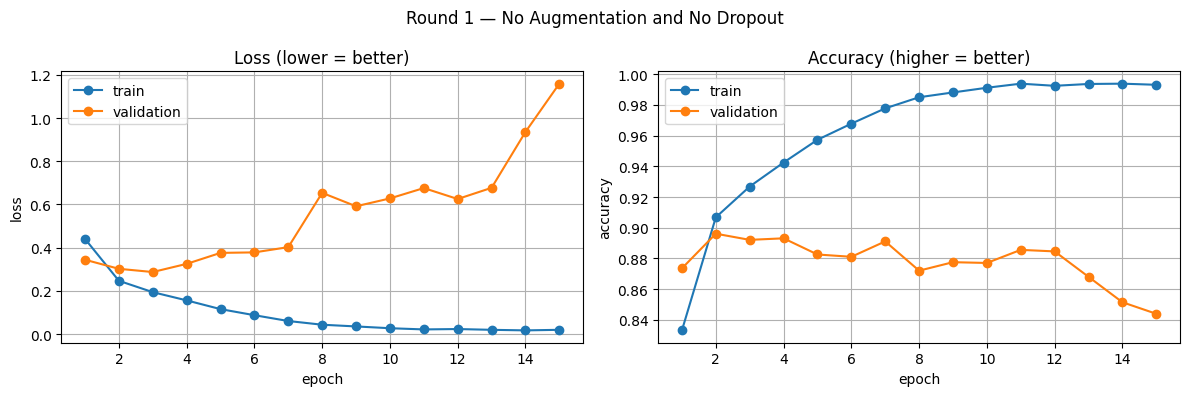

In [ ]:
# ============================================================
# Cell 12: Plot training and validation curves
# ============================================================
# Ei cell e training and validation er loss and accuracy graph draw kora hobe
# Graph dekhe model overfitting kortese kina bujha jabe


# History data use kore graph draw korar function
def plot_history(history, title=""):

    # Epoch number gula 1 theke start korbe
    # history te jotogula training loss ache, totogula epoch dhora hobe
    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    # Ek figure er moddhe side by side two ta graph create kortesi
    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    # ---------------- Loss graph ----------------

    # Training loss graph e plot kortesi
    # "o-" mane protita point e circle and point gula line diye connected thakbe
    ax1.plot(
        epochs,
        history["train_loss"],
        "o-",
        label="train"
    )

    # Validation loss same graph e plot kortesi
    ax1.plot(
        epochs,
        history["val_loss"],
        "o-",
        label="validation"
    )

    # Loss graph er title
    ax1.set_title(
        "Loss (lower = better)"
    )

    # X-axis e epoch and Y-axis e loss show korbe
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")

    # Train and validation line identify korar jonno legend show korbe
    ax1.legend()

    # Graph easily read korar jonno grid show korbe
    ax1.grid(True)


    # ---------------- Accuracy graph ----------------

    # Training accuracy graph e plot kortesi
    ax2.plot(
        epochs,
        history["train_acc"],
        "o-",
        label="train"
    )

    # Validation accuracy same graph e plot kortesi
    ax2.plot(
        epochs,
        history["val_acc"],
        "o-",
        label="validation"
    )

    # Accuracy graph er title
    ax2.set_title(
        "Accuracy (higher = better)"
    )

    # X-axis e epoch and Y-axis e accuracy show korbe
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")

    # Train and validation line identify korar jonno legend show korbe
    ax2.legend()

    # Graph easily read korar jonno grid show korbe
    ax2.grid(True)


    # Full figure er main title set korbe
    fig.suptitle(title)

    # Graph er title and axis overlap na korar jonno layout adjust korbe
    plt.tight_layout()

    # Final graph display korbe
    plt.show()


# Round 1 er saved history diye graph draw kortesi
plot_history(
    history_plain,
    "Round 1 — No Augmentation and No Dropout"
)

Conv1 filter shape: torch.Size([16, 3, 3, 3])


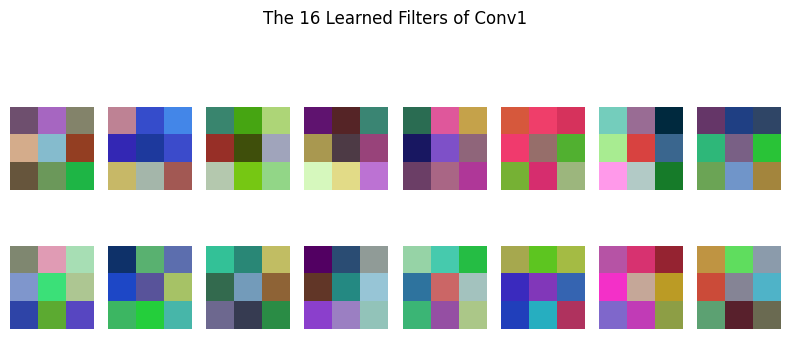

In [ ]:
# ============================================================
# Cell 13: Show learned filters from the first convolution layer
# ============================================================
# Ei cell e model er first convolution layer ki type er
# small pattern/filter learn korse seta visualize kora hobe


# Conv1 layer er learned weights copy kortesi
# clone() original weight ke change howa theke protect kore
# cpu() graph e display korar jonno tensor CPU te niye ashe
weights = model.conv1.weight.data.clone().cpu()


# Conv1 weight er shape print korbe
# Shape hobe: [16 filters, 3 colour channels, 3 height, 3 width]
print("Conv1 filter shape:", weights.shape)


# Sob filter er minimum and maximum value ber kortesi
weight_min = weights.min()
weight_max = weights.max()


# Filter values normally negative and positive range e thake
# Display korar jonno values ke 0 theke 1 range e convert kortesi
weights = (
    weights - weight_min
) / (
    weight_max - weight_min + 1e-8
)

# 1e-8 add kora hoyeche zero diye division avoid korar jonno


# Sob filter display korar figure create kortesi
plt.figure(figsize=(8, 4))


# Conv1 e total 16 ta filter ache
# Tai loop 16 bar run korbe
for i in range(16):

    # 2 row and 8 column er grid e current filter place korbe
    plt.subplot(2, 8, i + 1)

    # weights[i] er shape [C, H, W]
    # Matplotlib er jonno [H, W, C] format e convert kortesi
    plt.imshow(
        weights[i].permute(1, 2, 0)
    )

    # Axis line and number hide korbe
    plt.axis("off")


# Full figure er main title
plt.suptitle(
    "The 16 Learned Filters of Conv1"
)

# Filter image gula neatly arrange korbe
plt.tight_layout()

# Final filter grid display korbe
plt.show()

Conv1 feature-map shape: torch.Size([16, 128, 128])


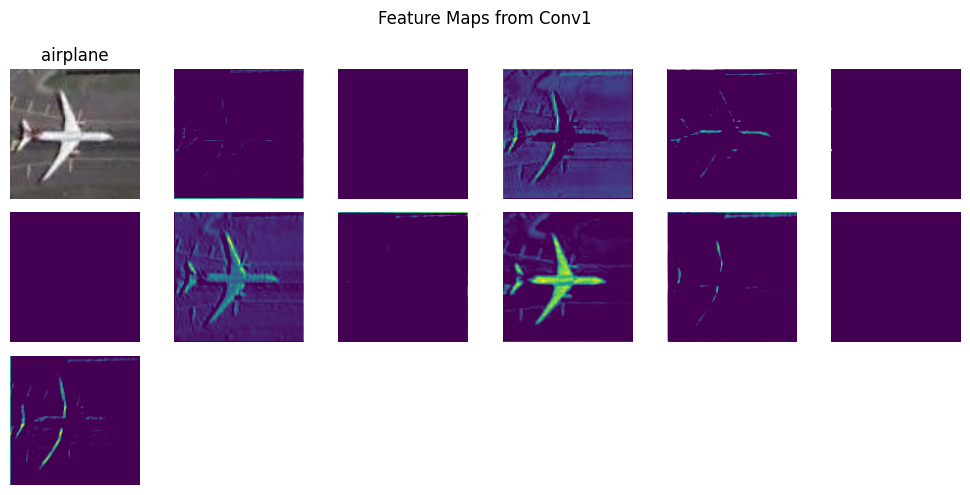

In [ ]:
# ============================================================
# Cell 14: Show how Conv1 responds to one validation image
# ============================================================
# Ei cell e ekta validation image Conv1 layer e dile
# layer ta kon kon area te response kore seta feature map diye dekhano hobe


# Validation dataset theke first image and tar label nicchi
img, label = val_ds[0]


# Model ekta batch expect kore
# tai single image er age extra batch dimension add kortesi
# .to(device) diye image GPU/CPU te pathacchi
img_batch = img.unsqueeze(0).to(device)


# Model ke evaluation mode e set kortesi
model.eval()


# Ekhane only output dekhbo, model train korbo na
# tai gradient calculation off rakhtesi
with torch.no_grad():

    # Image ke first convolution layer e pathacchi
    # ReLU negative value gula 0 kore dibe
    # cpu() diye result CPU te niye ashbe
    # [0] diye batch er first image er feature maps nicchi
    feature_maps = F.relu(
        model.conv1(img_batch)
    ).cpu()[0]


# Conv1 koyta feature map create korse and tader size print korbe
print(
    "Conv1 feature-map shape:",
    feature_maps.shape
)


# Original image and feature maps display korar figure create kortesi
plt.figure(figsize=(10, 5))


# 3 row and 6 column grid er first position e original image thakbe
plt.subplot(3, 6, 1)


# PyTorch image shape [C, H, W]
# Matplotlib er jonno [H, W, C] format e convert kortesi
plt.imshow(
    img.permute(1, 2, 0)
)


# Image er actual class name title e show korbe
plt.title(
    class_names[label]
)


# Original image er axis hide korbe
plt.axis("off")


# Conv1 er first 12 ta feature map display korbo
for i in range(12):

    # Original image er porer position theke feature maps place korbe
    plt.subplot(3, 6, i + 2)

    # Current feature map display korbe
    # viridis color map response intensity clearly dekhabe
    plt.imshow(
        feature_maps[i],
        cmap="viridis"
    )

    # Feature map er axis hide korbe
    plt.axis("off")


# Full figure er main title
plt.suptitle(
    "Feature Maps from Conv1"
)


# Image gula overlap na korar jonno layout adjust korbe
plt.tight_layout()


# Final original image and feature maps display korbe
plt.show()

Last convolution output shape: (64, 32, 32)


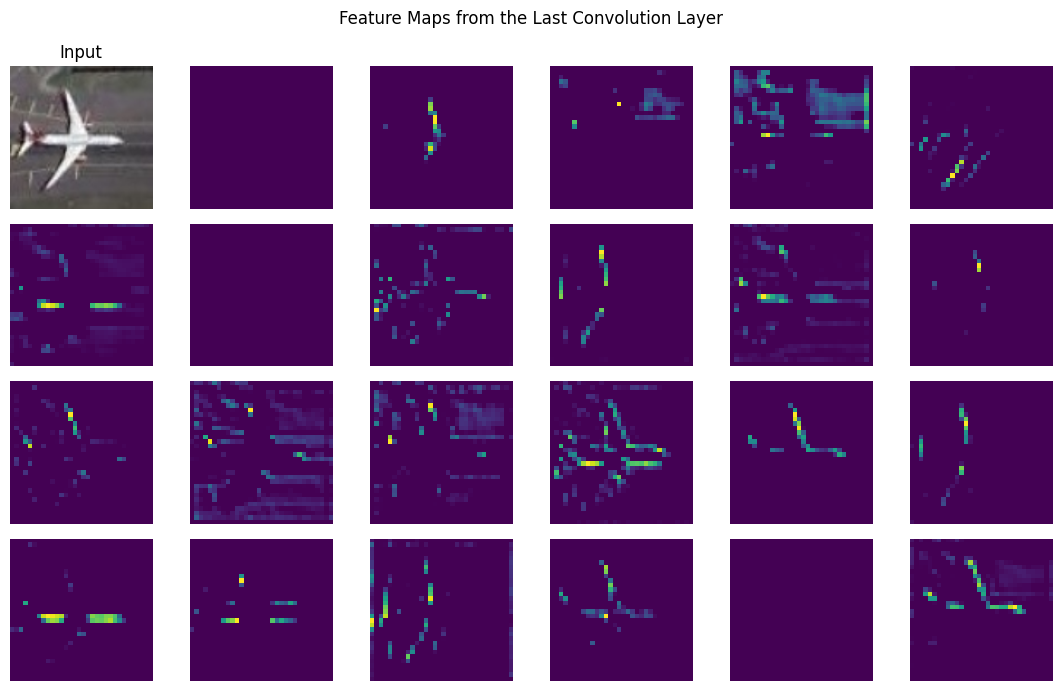

In [ ]:
# ============================================================
# Cell 15: Show feature maps from the last convolution layer
# ============================================================
# Ei cell e same validation image ke Conv1, Conv2, and Conv3 diye pass korano hobe
# tarpor last convolution layer kon deep features detect korse seta visualize kora hobe


# Model ke evaluation mode e set kortesi
model.eval()


# Validation dataset theke first image and tar label nicchi
img, label = val_ds[0]


# Model batch format expect kore
# tai single image er age batch dimension add kortesi
# .to(device) diye image GPU/CPU te pathacchi
x = img.unsqueeze(0).to(device)


# Ekhane model train korbo na, only feature maps collect korbo
# tai gradient calculation off rakhtesi
with torch.no_grad():

    # Image ke first convolution layer e pathacchi
    # ReLU negative values zero korbe
    # Pooling image size 128 theke 64 korbe
    x = model.pool(
        F.relu(model.conv1(x))
    )

    # First layer er output ekhon second convolution layer e jabe
    # Pooling image size 64 theke 32 korbe
    x = model.pool(
        F.relu(model.conv2(x))
    )

    # Second layer er output third convolution layer e pathacchi
    # Ekhane pooling use kora hoy nai, karon Conv3 er direct feature maps dekhbo
    # cpu() result ke display korar jonno CPU te niye ashe
    # [0] diye batch er first image er feature maps nicchi
    last_maps = F.relu(
        model.conv3(x)
    ).cpu()[0]


# Last convolution layer er output shape print korbe
# Expected shape: 64 ta feature map, protitar size 32 × 32
print(
    "Last convolution output shape:",
    tuple(last_maps.shape)
)


# Original image and feature maps display korar figure create kortesi
plt.figure(figsize=(11, 7))


# 4 row and 6 column grid er first position e original image thakbe
plt.subplot(4, 6, 1)


# PyTorch image shape [C, H, W]
# Matplotlib er jonno [H, W, C] format e convert kortesi
plt.imshow(
    img.permute(1, 2, 0)
)


# Original image er title
plt.title("Input")

# Axis line and number hide korbe
plt.axis("off")


# Conv3 er first 23 ta feature map show korbo
for i in range(23):

    # Original image er porer position theke feature maps place korbe
    plt.subplot(4, 6, i + 2)

    # Current feature map display korbe
    # Bright area mane oi feature sekhane strongly detect hoyeche
    plt.imshow(
        last_maps[i],
        cmap="viridis"
    )

    # Feature map er axis hide korbe
    plt.axis("off")


# Full figure er main title
plt.suptitle(
    "Feature Maps from the Last Convolution Layer"
)


# Image gula overlap na korar jonno layout adjust korbe
plt.tight_layout()


# Final original image and feature maps display korbe
plt.show()

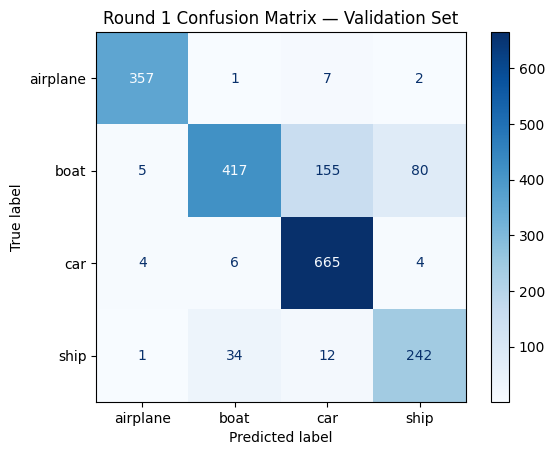

              precision    recall  f1-score   support

    airplane       0.97      0.97      0.97       367
        boat       0.91      0.63      0.75       657
         car       0.79      0.98      0.88       679
        ship       0.74      0.84      0.78       289

    accuracy                           0.84      1992
   macro avg       0.85      0.86      0.85      1992
weighted avg       0.86      0.84      0.84      1992



In [ ]:
# ============================================================
# Cell 16: Round 1 confusion matrix and classification report
# ============================================================
# Ei cell e Round 1 model er validation prediction collect kora hobe
# tarpor confusion matrix and classification report diye result analyze kora hobe


# Model evaluation er necessary metrics import kortesi
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# Model theke sob prediction and actual label collect korar function
def get_predictions(model, loader):

    # Model ke evaluation mode e set kortesi
    # Ekhane model train ba weight update korbe na
    model.eval()

    # Sob predicted label ekhane store hobe
    predictions = []

    # Sob actual label ekhane store hobe
    actual_labels = []

    # Prediction er somoy gradient calculation necessary na
    with torch.no_grad():

        # DataLoader theke images and labels batch by batch nicchi
        for imgs, labels in loader:

            # Images selected device e pathiye model er output nicchi
            outputs = model(
                imgs.to(device)
            )

            # Protita image er highest output score er class prediction hobe
            # cpu() diye result CPU te niye predictions list e add kortesi
            predictions.append(
                outputs.argmax(1).cpu()
            )

            # Current batch er actual labels collect kortesi
            actual_labels.append(labels)

    # Sob batch er prediction ekta single tensor e combine kortesi
    # Tarpor NumPy array e convert kore return kortesi
    return (
        torch.cat(predictions).numpy(),
        torch.cat(actual_labels).numpy()
    )


# Round 1 model diye validation dataset er predictions nicchi
# First returned value = predicted labels
# Second returned value = actual labels
round1_val_pred, round1_val_true = get_predictions(
    model,
    val_loader
)


# Class index er corresponding class names nicchi
class_names = val_ds.classes


# Actual and predicted labels compare kore confusion matrix create kortesi
round1_cm = confusion_matrix(
    round1_val_true,
    round1_val_pred
)


# Confusion matrix ke class names shoho display korar object create kortesi
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=round1_cm,
    display_labels=class_names
)


# Confusion matrix graph draw kortesi
# Blues colour map use hobe
# values_format="d" mane count integer number hisebe show korbe
display_matrix.plot(
    cmap="Blues",
    values_format="d"
)


# Confusion matrix er title
plt.title(
    "Round 1 Confusion Matrix — Validation Set"
)


# Final confusion matrix display korbe
plt.show()


# Protita class er precision, recall, F1-score,
# support, overall accuracy, macro average, and weighted average print korbe
print(
    classification_report(
        round1_val_true,
        round1_val_pred,
        target_names=class_names
    )
)

In [ ]:
# ============================================================
# Cell 17: Round 2 transformations
# Augmentation for training and clean validation
# ============================================================
#
# Faculty sample er same transformations:
# RandomHorizontalFlip
# RandomRotation
# ColorJitter
#
# Augmentation only training data te apply hobe.
# Validation and test clean thakbe.
# ============================================================


# Training images er jonno augmentation pipeline create kortesi
train_transform = transforms.Compose([

    # Sob image ke same 128 × 128 size e convert korbe
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    # Randomly image left-right flip korbe
    # Protibar sob image flip hobe na
    transforms.RandomHorizontalFlip(),

    # Image maximum 15 degree porjonto randomly rotate korbe
    transforms.RandomRotation(15),

    # Image er brightness and contrast slightly change korbe
    # Eta same image er different variation create korte help kore
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    # Image ke PyTorch tensor e convert korbe
    transforms.ToTensor(),
])


# Validation and test images er jonno clean transform
# Ekhane kono random augmentation use hobe na
val_transform = transforms.Compose([

    # Sob image ke same size e convert korbe
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    # Image ke PyTorch tensor e convert korbe
    transforms.ToTensor(),
])


# Training folder er image gula augmentation shoho load kortesi
train_ds_aug = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)


# Validation images clean transformation diye load kortesi
val_ds_clean = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)


# Test images o clean transformation diye load kortesi
test_ds_clean = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)


# Augmented training dataset ke batch e divide kortesi
# shuffle=True protita epoch er age image order randomly change korbe
train_loader_aug = DataLoader(
    train_ds_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# Validation dataset batch e load kortesi
# shuffle=False karon ekhane only performance check hobe
val_loader_clean = DataLoader(
    val_ds_clean,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Test dataset batch e load kortesi
test_loader_clean = DataLoader(
    test_ds_clean,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Pipeline properly ready hole summary print korbe
print("Augmented training pipeline ready.")
print("Training images:", len(train_ds_aug))
print("Validation images:", len(val_ds_clean))
print("Testing images:", len(test_ds_clean))

Augmented training pipeline ready.
Training images: 15035
Validation images: 1992
Testing images: 2075


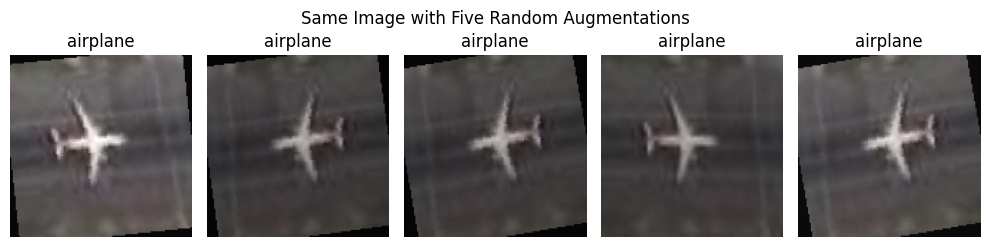

In [ ]:
# ============================================================
# Cell 18: Show the same image with random augmentation
# ============================================================
# Ei cell e same training image ke 5 bar load kora hobe
# protibar random transformation apply hoye image ta slightly different dekhabe


# 5 ta augmented image side by side show korar figure create kortesi
plt.figure(figsize=(10, 2.5))


# Same image 5 bar fetch korbo
for i in range(5):

    # Same image abar fetch korle
    # random transformation notun kore apply hobe
    augmented_image, augmented_label = (
        train_ds_aug[0]
    )

    # 1 row and 5 column er current subplot select korbe
    plt.subplot(1, 5, i + 1)

    # PyTorch image shape [C, H, W]
    # Matplotlib er jonno [H, W, C] format e convert kortesi
    plt.imshow(
        augmented_image.permute(1, 2, 0)
    )

    # Augmented image er actual class name title e show korbe
    plt.title(
        train_ds_aug.classes[
            augmented_label
        ]
    )

    # Axis line and number hide korbe
    plt.axis("off")


# Full figure er main title
plt.suptitle(
    "Same Image with Five Random Augmentations"
)


# Image gula overlap na korar jonno layout adjust korbe
plt.tight_layout()


# Final 5 ta augmented image display korbe
plt.show()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Epoch  1/30  train_loss=0.525 train_acc=0.792  |  val_loss=0.388 val_acc=0.855
Epoch  2/30  train_loss=0.335 train_acc=0.873  |  val_loss=0.318 val_acc=0.886
Epoch  3/30  train_loss=0.285 train_acc=0.892  |  val_loss=0.310 val_acc=0.885
Epoch  4/30  train_loss=0.265 train_acc=0.899  |  val_loss=0.296 val_acc=0.890
Epoch  5/30  train_loss=0.242 train_acc=0.910  |  val_loss=0.277 val_acc=0.897
Epoch  6/30  train_loss=0.225 train_acc=0.916  |  val_loss=0.305 val_acc=0.891
Epoch  7/30  train_loss=0.204 t

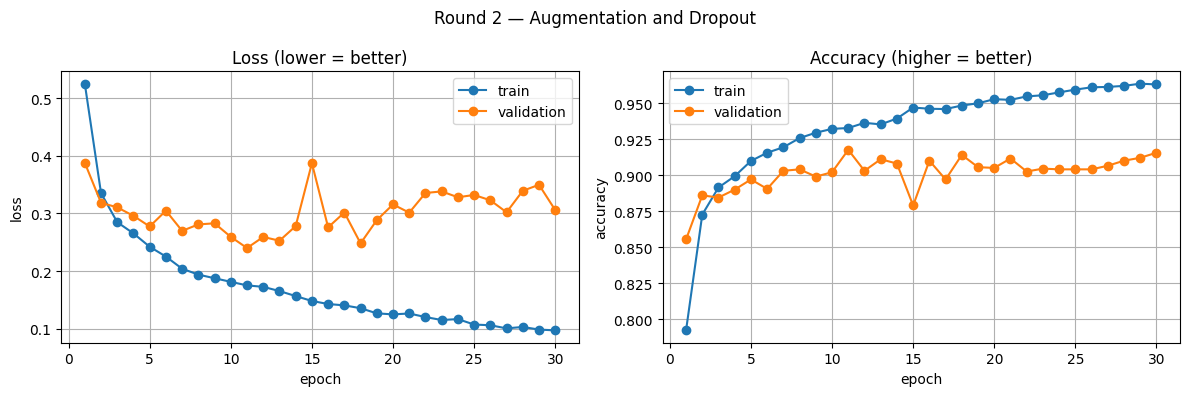

In [ ]:
# ============================================================
# Cell 19: Round 2 training
# Augmentation and Dropout
# ============================================================
# Ei cell e augmented training data and dropout use kore
# fresh CNN model ke Round 2 er jonno train kora hobe


# Fresh CNN model create kortesi
# p_dropout=0.5 means training er somoy
# 50% classification features randomly off thakbe
model_aug = SimpleCNN(
    p_dropout=0.5
).to(device)


# Round 2 model er full structure print korbe
print(model_aug)


# Faculty sample er moto Round 2 model 30 epochs train korbe
# train_loader_aug e augmented training images ache
# val_loader_clean e clean validation images ache
history_aug = train_model(
    model_aug,
    train_loader_aug,
    val_loader_clean,
    epochs=30
)


# Round 2 er training and validation
# loss and accuracy curves display korbe
plot_history(
    history_aug,
    "Round 2 — Augmentation and Dropout"
)

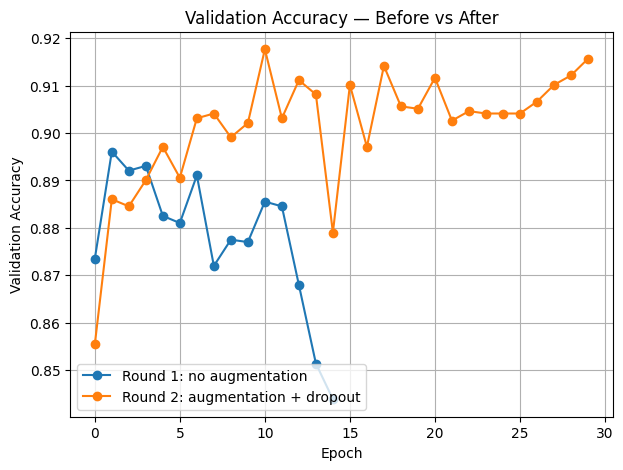

Best validation accuracy (Round 1): 0.896
Best validation accuracy (Round 2): 0.918


In [ ]:
# ============================================================
# Cell 20: Compare validation accuracy
# ============================================================
# Ei cell e Round 1 and Round 2 er validation accuracy
# same graph e compare kora hobe


# Comparison graph er figure size set kortesi
plt.figure(figsize=(7, 5))


# Round 1 er validation accuracy plot kortesi
# Ekhane augmentation and dropout use hoy nai

#"-"     circle points gula straight line diye connect korbe
#"o"     protita epoch er value circle marker diye show korbe
#"s-"    square points with line
#"^-"   triangle points with line
plt.plot(
    history_plain["val_acc"],
    "o-",
    label="Round 1: no augmentation"
)


# Round 2 er validation accuracy plot kortesi
# Ekhane augmentation and dropout use hoyeche
plt.plot(
    history_aug["val_acc"],
    "o-",
    label="Round 2: augmentation + dropout"
)


# Graph er title set kortesi
plt.title(
    "Validation Accuracy — Before vs After"
)


# X-axis e epoch number show korbe
plt.xlabel("Epoch")

# Y-axis e validation accuracy show korbe
plt.ylabel("Validation Accuracy")


# Kon line Round 1 and kon line Round 2 seta show korbe
plt.legend()


# Graph easily read korar jonno grid show korbe
plt.grid(True)


# Final comparison graph display korbe
plt.show()


# Round 1 er sob validation accuracy theke highest value print korbe
print(
    f"Best validation accuracy (Round 1): "
    f"{max(history_plain['val_acc']):.3f}"
)


# Round 2 er sob validation accuracy theke highest value print korbe
print(
    f"Best validation accuracy (Round 2): "
    f"{max(history_aug['val_acc']):.3f}"
)

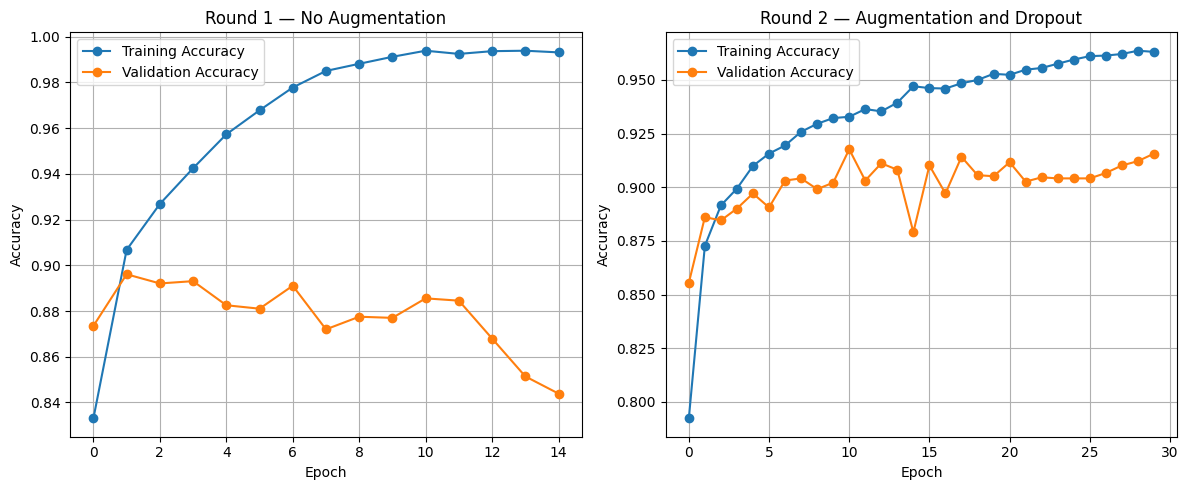

In [ ]:
# ============================================================
# Cell 21: Compare training-validation gaps
# ============================================================
# Ei cell e Round 1 and Round 2 er training and validation accuracy
# side by side compare kora hobe
# Eta dekhe kon round e overfitting beshi ba kom seta bujha jabe


# Ek figure er moddhe two ta graph create korar size set kortesi
plt.figure(figsize=(12, 5))


# ---------------- Round 1 ----------------

# 1 row, 2 column er first graph select kortesi
plt.subplot(1, 2, 1)


# Round 1 er training accuracy plot kortesi
plt.plot(
    history_plain["train_acc"],
    "o-",
    label="Training Accuracy"
)


# Round 1 er validation accuracy same graph e plot kortesi
plt.plot(
    history_plain["val_acc"],
    "o-",
    label="Validation Accuracy"
)


# First graph er title
plt.title(
    "Round 1 — No Augmentation"
)


# X-axis e epoch number show korbe
plt.xlabel("Epoch")

# Y-axis e accuracy show korbe
plt.ylabel("Accuracy")


# Training and validation line identify korar jonno legend show korbe
plt.legend()


# Graph easily read korar jonno grid show korbe
plt.grid(True)


# ---------------- Round 2 ----------------

# 1 row, 2 column er second graph select kortesi
plt.subplot(1, 2, 2)


# Round 2 er training accuracy plot kortesi
plt.plot(
    history_aug["train_acc"],
    "o-",
    label="Training Accuracy"
)


# Round 2 er validation accuracy same graph e plot kortesi
plt.plot(
    history_aug["val_acc"],
    "o-",
    label="Validation Accuracy"
)


# Second graph er title
plt.title(
    "Round 2 — Augmentation and Dropout"
)


# X-axis e epoch number show korbe
plt.xlabel("Epoch")

# Y-axis e accuracy show korbe
plt.ylabel("Accuracy")


# Training and validation line identify korar jonno legend show korbe
plt.legend()


# Graph easily read korar jonno grid show korbe
plt.grid(True)


# Two ta graph jate overlap na kore, layout adjust korbe
plt.tight_layout()


# Final comparison graphs display korbe
plt.show()

Round 2 last convolution output shape: (64, 32, 32)


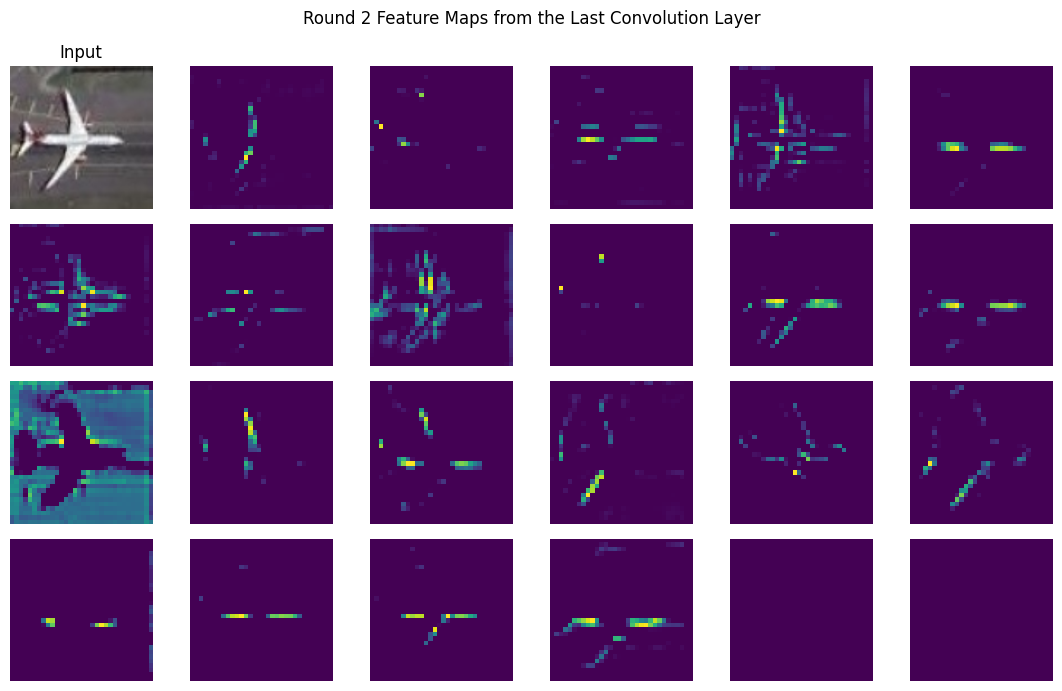

In [ ]:
# ============================================================
# Cell 22: Round 2 final convolution feature maps
# ============================================================
# Ei cell e Round 2 model er last convolution layer
# validation image theke ki deep features learn korse seta dekhano hobe


# Round 2 model ke evaluation mode e set kortesi
model_aug.eval()


# Clean validation dataset theke first image and label nicchi
img, label = val_ds_clean[0]


# Single image er age batch dimension add kortesi
# tarpor image selected device e pathacchi
x = img.unsqueeze(0).to(device)


# Ekhane model train korbo na, only feature maps collect korbo
with torch.no_grad():

    # Image Conv1, ReLU, and pooling diye process hobe
    x = model_aug.pool(
        F.relu(model_aug.conv1(x))
    )

    # Conv1 er output Conv2, ReLU, and pooling diye process hobe
    x = model_aug.pool(
        F.relu(model_aug.conv2(x))
    )

    # Conv2 er output Conv3 te pathacchi
    # Ekhane Conv3 er direct feature maps collect kortesi
    last_maps_aug = F.relu(
        model_aug.conv3(x)
    ).cpu()[0]


# Round 2 er last convolution output shape print korbe
# Expected shape: 64 ta feature map, protitar size 32 × 32
print(
    "Round 2 last convolution output shape:",
    tuple(last_maps_aug.shape)
)


# Original image and feature maps display korar figure create kortesi
plt.figure(figsize=(11, 7))


# 4 row and 6 column grid er first position e original image show korbe
plt.subplot(4, 6, 1)


# PyTorch image shape [C, H, W]
# Matplotlib er jonno [H, W, C] format e convert kortesi
plt.imshow(
    img.permute(1, 2, 0)
)


# Original image er title
plt.title("Input")

# Axis line and number hide korbe
plt.axis("off")


# Conv3 er first 23 ta feature map show korbo
for i in range(23):

    # Original image er porer position theke feature maps place korbe
    plt.subplot(4, 6, i + 2)

    # Current feature map display korbe
    # Bright area mane oi feature strongly detect hoyeche
    plt.imshow(
        last_maps_aug[i],
        cmap="viridis"
    )

    # Axis hide korbe
    plt.axis("off")


# Full figure er main title
plt.suptitle(
    "Round 2 Feature Maps from the Last Convolution Layer"
)


# Image gula overlap na korar jonno layout adjust korbe
plt.tight_layout()


# Final original image and feature maps display korbe
plt.show()

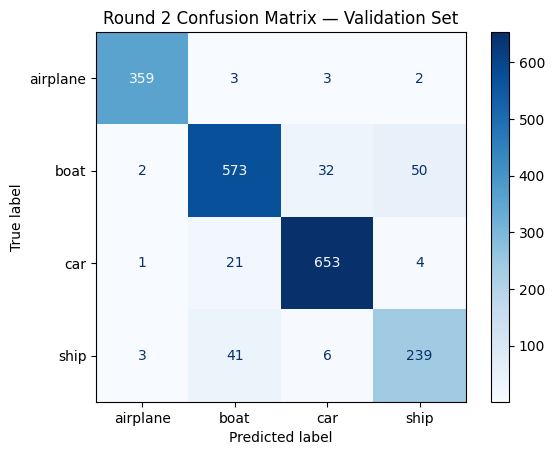

              precision    recall  f1-score   support

    airplane       0.98      0.98      0.98       367
        boat       0.90      0.87      0.88       657
         car       0.94      0.96      0.95       679
        ship       0.81      0.83      0.82       289

    accuracy                           0.92      1992
   macro avg       0.91      0.91      0.91      1992
weighted avg       0.92      0.92      0.92      1992



In [ ]:
# ============================================================
# Cell 23: Round 2 confusion matrix and classification report
# ============================================================
# Ei cell e Round 2 model er validation result analyze kora hobe
# confusion matrix diye correct and wrong prediction dekha hobe
# classification report diye precision, recall, and F1-score dekha hobe


# Round 2 model diye clean validation dataset er prediction nicchi
# First value predicted labels, second value actual labels
round2_val_pred, round2_val_true = get_predictions(
    model_aug,
    val_loader_clean
)


# Validation dataset er class names nicchi
class_names = val_ds_clean.classes


# Actual and predicted labels compare kore confusion matrix create kortesi
round2_cm = confusion_matrix(
    round2_val_true,
    round2_val_pred
)


# Confusion matrix ke class names shoho display korar object create kortesi
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=round2_cm,
    display_labels=class_names
)


# Confusion matrix graph draw kortesi
# Blues colour map use hobe
# values_format="d" mane integer count show korbe
display_matrix.plot(
    cmap="Blues",
    values_format="d"
)


# Confusion matrix er title
plt.title(
    "Round 2 Confusion Matrix — Validation Set"
)


# Final confusion matrix display korbe
plt.show()


# Protita class er precision, recall, F1-score,
# support, overall accuracy, macro average, and weighted average print korbe
print(
    classification_report(
        round2_val_true,
        round2_val_pred,
        target_names=class_names
    )
)

Ei cell 24 er main purpose:

Round 1 model ke completely unseen
test data diye check kora

Round 2 model ke same test data diye check kora

Test accuracy compare kora
Kon class e model beshi mistake korse confusion matrix diye dekha

Precision, recall, and F1-score diye class-wise performance analyze kora





ROUND 1 TEST RESULT
Test Accuracy: 0.8737

Classification Report:
              precision    recall  f1-score   support

    airplane       0.98      0.98      0.98       553
        boat       0.80      0.50      0.62       334
         car       0.81      0.97      0.89       798
        ship       0.92      0.84      0.87       390

    accuracy                           0.87      2075
   macro avg       0.88      0.82      0.84      2075
weighted avg       0.87      0.87      0.87      2075



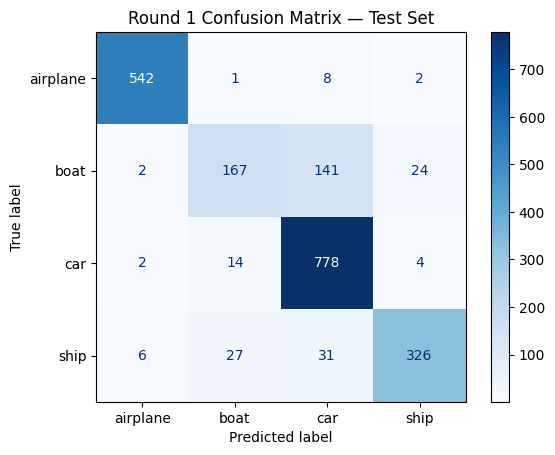

ROUND 2 TEST RESULT
Test Accuracy: 0.9234

Classification Report:
              precision    recall  f1-score   support

    airplane       0.99      0.98      0.99       553
        boat       0.76      0.83      0.79       334
         car       0.95      0.96      0.96       798
        ship       0.92      0.84      0.88       390

    accuracy                           0.92      2075
   macro avg       0.91      0.90      0.90      2075
weighted avg       0.93      0.92      0.92      2075



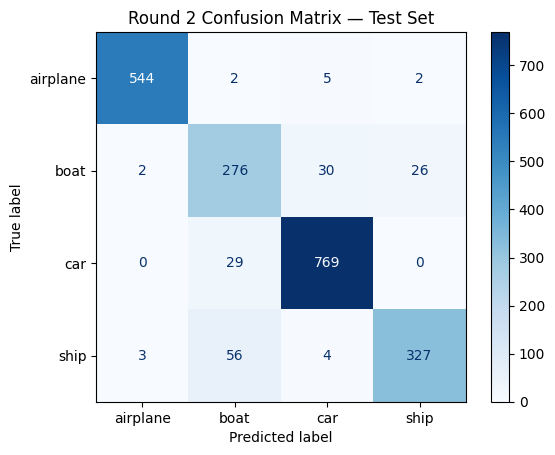

In [ ]:
# ============================================================
# Cell 24: Final evaluation on the separate test set
# ============================================================
#
# Training and validation curves overfitting analyze korbe.
# Test set final unseen performance check korbe.
#
# Ekhane Round 1 and Round 2 model ke same test dataset diye
# evaluate kore final performance compare kora hobe.
# ============================================================


# ---------------- Round 1 test result ----------------


# Round 1 model diye test dataset er prediction nicchi
# First value predicted labels, second value actual labels
round1_test_pred, round1_test_true = get_predictions(
    model,
    test_loader
)


# Predicted and actual label compare kore
# Round 1 er overall test accuracy calculate kortesi
round1_test_accuracy = (
    round1_test_pred == round1_test_true
).mean()


# Round 1 result er heading print korbe
print("=" * 65)
print("ROUND 1 TEST RESULT")
print("=" * 65)


# Round 1 test accuracy 4 decimal place e show korbe
print(
    f"Test Accuracy: {round1_test_accuracy:.4f}"
)


# Classification report er heading
print("\nClassification Report:")


# Protita class er precision, recall, F1-score,
# support, and overall accuracy print korbe
print(
    classification_report(
        round1_test_true,
        round1_test_pred,
        target_names=test_ds.classes
    )
)


# Round 1 er actual and predicted labels diye
# confusion matrix create kortesi
round1_test_cm = confusion_matrix(
    round1_test_true,
    round1_test_pred
)


# Confusion matrix ke class names shoho display korar object
round1_display = ConfusionMatrixDisplay(
    confusion_matrix=round1_test_cm,
    display_labels=test_ds.classes
)


# Round 1 confusion matrix graph draw kortesi
# values_format="d" integer count show korbe
round1_display.plot(
    cmap="Blues",
    values_format="d"
)


# Round 1 test confusion matrix er title
plt.title(
    "Round 1 Confusion Matrix — Test Set"
)


# Final Round 1 confusion matrix display korbe
plt.show()



# ---------------- Round 2 test result ----------------


# Round 2 model diye clean test dataset er prediction nicchi
round2_test_pred, round2_test_true = get_predictions(
    model_aug,
    test_loader_clean
)


# Round 2 er overall test accuracy calculate kortesi
round2_test_accuracy = (
    round2_test_pred == round2_test_true
).mean()


# Round 2 result er heading print korbe
print("=" * 65)
print("ROUND 2 TEST RESULT")
print("=" * 65)


# Round 2 test accuracy 4 decimal place e show korbe
print(
    f"Test Accuracy: {round2_test_accuracy:.4f}"
)


# Classification report er heading
print("\nClassification Report:")


# Round 2 er protita class er precision, recall,
# F1-score, support, and overall accuracy print korbe
print(
    classification_report(
        round2_test_true,
        round2_test_pred,
        target_names=test_ds_clean.classes
    )
)


# Round 2 er actual and predicted labels diye
# confusion matrix create kortesi
round2_test_cm = confusion_matrix(
    round2_test_true,
    round2_test_pred
)


# Round 2 confusion matrix display korar object
round2_display = ConfusionMatrixDisplay(
    confusion_matrix=round2_test_cm,
    display_labels=test_ds_clean.classes
)


# Round 2 confusion matrix graph draw kortesi
round2_display.plot(
    cmap="Blues",
    values_format="d"
)


# Round 2 test confusion matrix er title
plt.title(
    "Round 2 Confusion Matrix — Test Set"
)


# Final Round 2 confusion matrix display korbe
plt.show()

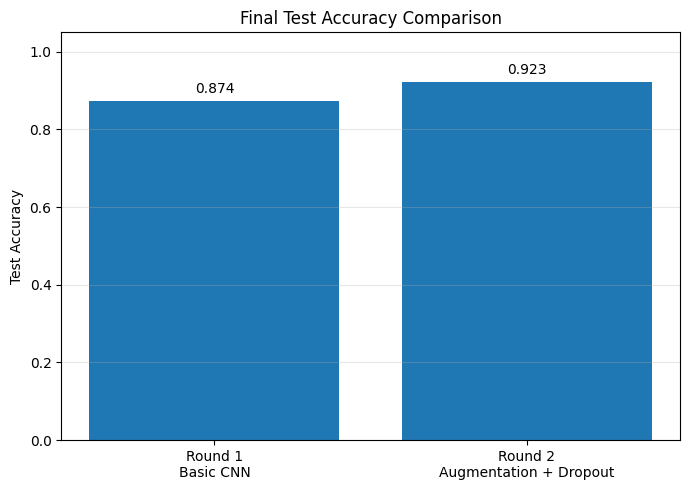

Round 1 Test Accuracy: 0.874
Round 2 Test Accuracy: 0.923


In [ ]:
# ============================================================
# Cell 25: Final accuracy comparison
# ============================================================
# Ei cell e Round 1 and Round 2 model er final test accuracy
# bar chart diye side by side compare kora hobe


# X-axis e show korar jonno model names list e rakhtesi
# \n use korar karone name two line e show hobe
model_names = [
    "Round 1\nBasic CNN",
    "Round 2\nAugmentation + Dropout"
]


# Two model er calculated test accuracy list e rakhtesi
test_accuracies = [
    round1_test_accuracy,
    round2_test_accuracy
]


# Accuracy comparison graph er figure size set kortesi
plt.figure(figsize=(7, 5))


# Model names and corresponding test accuracy diye bar chart create kortesi
plt.bar(
    model_names,
    test_accuracies
)


# Bar chart er title set kortesi
plt.title(
    "Final Test Accuracy Comparison"
)


# Y-axis e test accuracy show korbe
plt.ylabel("Test Accuracy")


# Accuracy 0 to 1 range e thake
# 1.05 porjonto rakhar karone bar er upor value lekhar space thakbe
plt.ylim(0, 1.05)


# Shudhu Y-axis e halka grid line show korbe
# alpha=0.3 grid line ke less visible korbe
plt.grid(
    axis="y",
    alpha=0.3
)


# Bar er upor exact accuracy show korbe
# enumerate protita accuracy er index and value dibe
for index, accuracy in enumerate(test_accuracies):

    # Current bar er upor accuracy value text hisebe show korbe
    plt.text(
        index,
        accuracy + 0.02,
        f"{accuracy:.3f}",
        ha="center"
    )


# Graph er elements jate overlap na kore layout adjust korbe
plt.tight_layout()


# Final bar chart display korbe
plt.show()


# Round 1 er final test accuracy 3 decimal place e print korbe
print(
    f"Round 1 Test Accuracy: "
    f"{round1_test_accuracy:.3f}"
)


# Round 2 er final test accuracy 3 decimal place e print korbe
print(
    f"Round 2 Test Accuracy: "
    f"{round2_test_accuracy:.3f}"
)